In [2]:

import os
hf_token = os.getenv("HF_TOKEN")

import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import gensim.downloader     #na nacitanie predtrenovaneho word2vec modelu
from nltk.tokenize import word_tokenize
import nltk     #natural language processing
nltk.download('punkt', quiet=True)

from src.data_loader import load_data
from src.LM.embeddings.embedder_preprocess import clean_text
from src.LM.embeddings.embedder_preprocess import load_word2vec_model
from src.LM.embeddings.embedder_preprocess import text_to_vector
from src.LM.embeddings.embedder_preprocess import prepare_data_word2vec

# nacitanie datasetu

df = load_data("/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv")


Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...


Loading pretrained MiniLM model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
Minilm embedder loaded on device: cuda
Loaded embedding cache.


/tmp/ipykernel_556666/1878694912.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 200), random_state=42))


Saved cache with 694 entries.

 Embeddings ready:
Train embeddings shape: (311, 384)
Test embeddings shape: (78, 384)


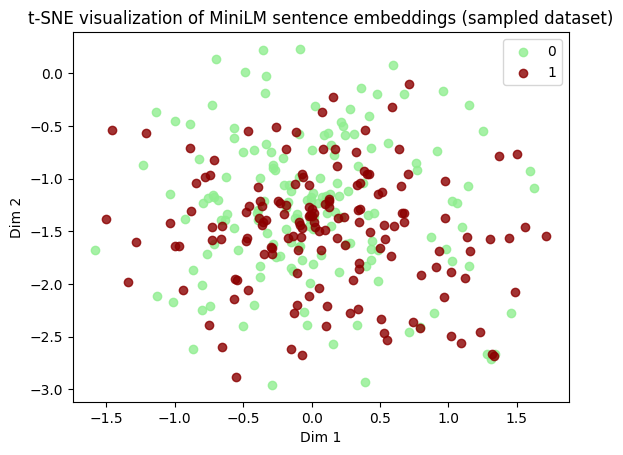

In [7]:

# vyber mensieho poctu vzoriek - 30 vzoriek z kazdej kategorie
from src.LM.embeddings.embedder_preprocess import prepare_data_minilm_simple

import torch
from src.LM.embeddings.embedder_preprocess import load_minilm_embedder

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device )


sampled_df = (
    df.groupby("Category", group_keys=False)
      .apply(lambda x: x.sample(min(len(x), 200), random_state=42))
      .reset_index(drop=True)
)



# vytvorenie embeddingov
# vycistenie textu
# rozdelenie na train / test
# nacitanie modelu

X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(sampled_df, tokenizer, minilm_model, device = device)
print("\n Embeddings ready:")
print("Train embeddings shape:", X_train_vec.shape)
print("Test embeddings shape:", X_test_vec.shape)

# t-SNE vizualizacia (distributed stochastic neighbour embedding)
# 300D -> 2D reprezentacia

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# perplexity musi byt menej ako pocet vzoriek
# kolko blizkych bodov povazuje bod za svojich susedov
perplexity = min(200, len(X_train_vec) - 1)

tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
X_tsne = tsne.fit_transform(X_train_vec)

# vizualizacia 
# bodka - jedna vzorka (veta)
# podobne vety (z rovnakej kategorie) su blizko pri sebe

colors = {
    '0': 'lightgreen',
    '1': 'darkred'
}

y_train_np = y_train.to_numpy()
for label in np.unique(y_train_np):
    idx = np.where(y_train_np == label)[0]  # take the array
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, alpha=0.8, color=colors.get(str(label), 'gray'))


plt.title("t-SNE visualization of MiniLM sentence embeddings (sampled dataset)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.show()

